In [1]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array

# 1. Khởi tạo SparkSession kết nối với Spark Master
spark = SparkSession.builder \
    .appName("Phan_Cum_Khach_Hang") \
    .master("spark://26.37.93.102:7077") \
    .config("spark.executor.memory", "3g") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Đã khởi tạo thành công \n")

# 2. Đọc dữ liệu từ HDFS
df = spark.read.parquet("hdfs://master:9000/data/test.parquet")
df.createOrReplaceTempView("ecommerce_cleaned")
print("Đã load TempView ecommerce_cleaned\n")

Đã khởi tạo thành công 

Đã load TempView ecommerce_cleaned



In [2]:
# Trích xuất đặc trưng hành vi theo user_id
user_features = df.groupBy("user_id").agg(
   # Tổng chi tiêu thực tế (chỉ tính sự kiện mua hàng - target = 1)
   F.sum(
       F.when(F.col("target") == 1, F.col("price")).otherwise(0)
   ).alias("total_spend"),
   # Số lượt mua hàng thành công
   F.count(
       F.when(F.col("target") == 1, True)
   ).alias("num_purchased"),
   # Giá trung bình trên toàn bộ sản phẩm đã tương tác
   F.round(F.avg("price"), 2).alias("avg_price"),
   # Tổng lượt tương tác
   # Dataset chỉ có cart & purchase, không có event view riêng nên mỗi dòng sự kiện xem như mỗi view
   F.count("*").alias("total_interactions"),
   # Tổng lượt thêm vào giỏ hàng
   F.count(
       F.when(F.col("event_type") == "cart", True)
   ).alias("total_add_to_cart")
)
print("Các đặc trưng hành vi người dùng (10 dòng đầu):")
display_user_features = user_features.limit(10).toPandas()
print(display_user_features.to_string(index=False))
print(f"\n Tổng số người dùng trong bộ dữ liệu: {user_features.count():,}")

Các đặc trưng hành vi người dùng (10 dòng đầu):
  user_id  total_spend  num_purchased  avg_price  total_interactions  total_add_to_cart
549120754         0.00              0     411.27                   1                  1
580850376         0.00              0     175.52                   2                  2
616060746       244.46              1     294.11                   3                  2
556309303       149.24              2      75.98                   7                  5
514626548         0.00              0     175.55                   1                  1
512920015       166.77              1     166.38                   2                  1
518939548       280.52              1     273.55                  24                 23
624866902         0.00              0     514.79                   1                  1
616652580         0.00              0      61.01                   1                  1
543578026         0.00              0      60.80                   1    

In [3]:
# Tạo vector đặc trưng và chuẩn hóa
FEATURE_COLS = [
   "total_spend",
   "num_purchased",
   "avg_price",
   "total_interactions",
   "total_add_to_cart"
]
# Bước 1: Gộp các cột đặc trưng thành một vector
assembler = VectorAssembler(
   inputCols=FEATURE_COLS,
   outputCol="features_raw"
)
# Bước 2: Chuẩn hóa vector
scaler = StandardScaler(
   inputCol="features_raw",
   outputCol="features",
   withStd=True,   # Chia cho độ lệch chuẩn → Giúp co giãn dữ liệu sao cho mức độ phân tán (phương sai) của chúng bằng 1
   withMean=True   # Trừ giá trị trung bình → Giúp dời tâm của toàn bộ dữ liệu về điểm 0
)
# Thiết lập Pipeline
pipeline_prep = Pipeline(stages=[assembler, scaler])
model_prep = pipeline_prep.fit(user_features)
df_scaled = model_prep.transform(user_features)


print(f"   Số đặc trưng đầu vào : {len(FEATURE_COLS)}")
print(f"   Số người dùng        : {df_scaled.count():,}")


display_df_scaled = df_scaled.select("user_id", "features").limit(5).toPandas()
print(display_df_scaled.to_string(index=False))

   Số đặc trưng đầu vào : 5
   Số người dùng        : 979,981
  user_id                                                                                                       features
543406911           [1.0255456381840231, 0.9223889375664365, 0.5006354536742093, 1.0036408502637524, 0.6537949325842223]
531555959   [-0.26163992681366555, -0.44708719369817523, -0.3069850525661785, -0.44332673385564036, -0.2622701580688527]
537332360     [-0.13392974750480174, 0.009404850056695349, 0.2713806637657138, 0.28015705820405595, 0.34843990236653066]
631598645    [-0.26163992681366555, -0.44708719369817523, 0.11983518445897658, 0.03899579418415716, 0.34843990236653066]
584081809 [-0.26163992681366555, -0.44708719369817523, -0.013048792981456975, -0.2021654698357416, 0.043084872148838986]


In [4]:
# TÌM k TỐT NHẤT: Kết hợp 2 phương pháp với k từ 2 đến 10
# 1. Elbow Method (Dựa vào WSSSE: tìm điểm gập của đồ thị)
# 2. Silhouette Analysis (Dựa vào Silhouette Score: tìm k có điểm cao nhất)


# Khởi tạo công cụ đo lường điểm Silhouette
# featuresCol: Tên cột chứa dữ liệu đầu vào đã chuẩn hóa
# metricName: Chỉ định tính điểm Silhouette
# distanceMeasure: Dùng bình phương khoảng cách Euclidean để tính khoảng cách giữa các điểm dữ liệu
evaluator = ClusteringEvaluator(
   featuresCol="features",
   metricName="silhouette",
   distanceMeasure="squaredEuclidean"
)
k_range = range(2, 11)
# Tạo 2 danh sách trống để lưu lại điểm WSSSE và Silhouette của mỗi vòng lặp
wssse_list = []
silhouette_list = []
# In ra tiêu đề bảng kết quả
print(f"{'k':>4} | {'WSSSE':>15} | {'Silhouette Score':>18}")
print("-" * 42)
for k in k_range:
   # Cấu hình các thông số cơ bản cho thuật toán K-Means
   # k: Số cụm hiện tại đang thử nghiệm
   # seed=42: Đặt con số cố định để kết quả không bị xáo trộn ngẫu nhiên ở các lần chạy sau
   # maxIter=20: Giới hạn số lần lặp tối đa để tìm cụm là 20 lần
   # tol=1e-4: Ngưỡng sai số cho phép để thuật toán dừng lại nếu không còn thay đổi đáng kể
   kmeans = KMeans(
       featuresCol="features",
       k=k,
       seed=42,
       maxIter=20,
       tol=1e-4
   )
   # Đưa tập dữ liệu vào để thuật toán bắt đầu học và gom cụm
   model_k = kmeans.fit(df_scaled)
   # Áp dụng mô hình vừa học xong để dán nhãn cụm (0, 1, 2...) cho dữ liệu
   predictions_k = model_k.transform(df_scaled)
   # Lấy điểm WSSSE trực tiếp từ kết quả huấn luyện của mô hình
   wssse = model_k.summary.trainingCost
   # Dùng công cụ evaluator đã khởi tạo ở trên để chấm điểm Silhouette
   silhouette = evaluator.evaluate(predictions_k)
   # Thêm 2 điểm số vừa tính được vào danh sách trống đã tạo lúc đầu
   wssse_list.append(wssse)
   silhouette_list.append(silhouette)
   # In điểm số của mức k hiện tại ra màn hình
   print(f"{k:>4} | {wssse:>15.2f} | {silhouette:>18.4f}")
print("\n Quá trình đánh giá cụm hoàn tất!")

Đang chạy Elbow Method...
   k |           WSSSE |   Silhouette Score
------------------------------------------
   2 |      3912000.13 |             0.9415
   3 |      3236980.60 |             0.7297
   4 |      3028488.49 |             0.7322
   5 |      2404048.92 |             0.7116
   6 |      2196831.24 |             0.5951
   7 |      1920957.95 |             0.6808
   8 |      1698251.58 |             0.6586
   9 |      1549115.44 |             0.4782
  10 |      1412332.68 |             0.5057

 Elbow Method hoàn tất!


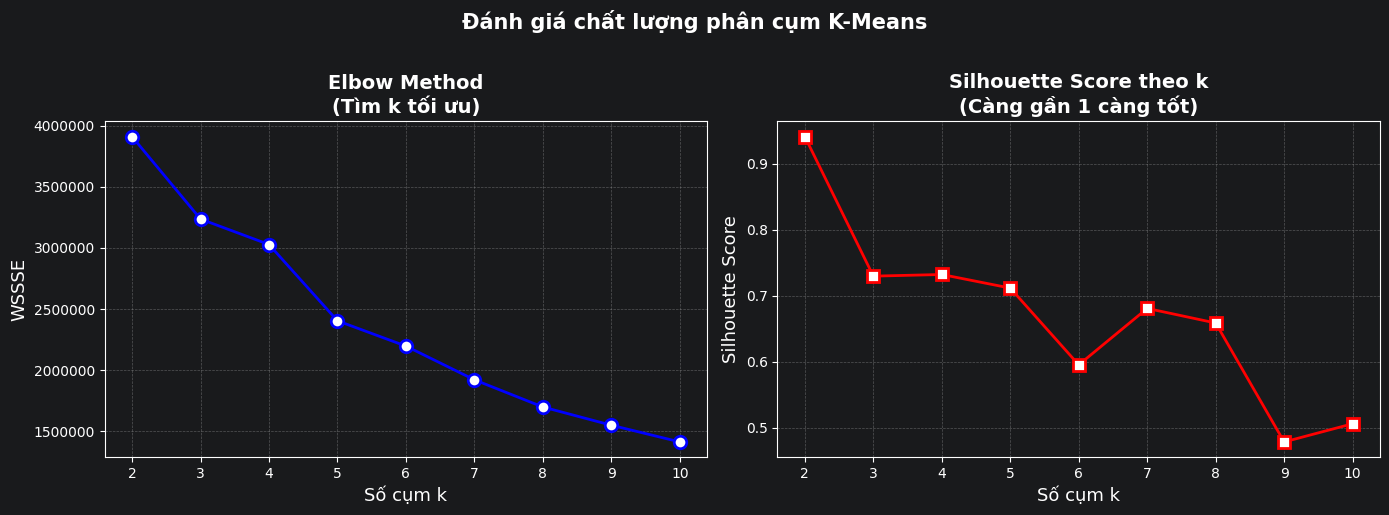

Đã lưu: elbow_silhouette.png


In [5]:
# Trực quan hóa Elbow Method và Silhouette Score
# Tạo một khung hình chứa 2 biểu đồ nằm ngang sát nhau (1 hàng, 2 cột)
# Kích thước chiều rộng là 14 và chiều cao là 5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


# --- Biểu đồ 1: Elbow (WSSSE) ---
# 'bo-': Vẽ đường màu xanh dương (b), có điểm nhấn là hình tròn (o), nối với nhau bằng đường thẳng (-)
# Các tham số sau: độ dày đường vẽ bằng 2, kích thước điểm tròn bằng 9, ruột điểm tròn màu trắng, viền điểm tròn dày 2
ax1.plot(list(k_range), wssse_list, 'bo-',
        linewidth=2, markersize=9, markerfacecolor='white',
        markeredgewidth=2)
# Đặt tên cho trục ngang (trục x)
ax1.set_xlabel('Số cụm k', fontsize=13)
# Đặt tên cho trục dọc (trục y)
ax1.set_ylabel('WSSSE', fontsize=13)
# Đặt tiêu đề cho biểu đồ bên trái
ax1.set_title('Elbow Method\n(Tìm k tối ưu)', fontsize=14, fontweight='bold')
# Bắt buộc trục ngang phải hiển thị đầy đủ từng số nguyên k
ax1.set_xticks(list(k_range))
# Định dạng các số hiển thị trên trục dọc làm tròn thành số nguyên, bỏ các số thập phân
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
# Bật grid với nét đứt và làm mờ nét kẻ lưới đi 60% (alpha=0.4)
ax1.grid(True, linestyle='--', alpha=0.4)


# --- Biểu đồ 2: Silhouette Score ---
# 'rs-': Vẽ đường màu đỏ (r), có điểm nhấn là hình vuông (s), nối với nhau bằng đường thẳng (-)
ax2.plot(list(k_range), silhouette_list, 'rs-',
        linewidth=2, markersize=9, markerfacecolor='white',
        markeredgewidth=2)
# Đặt tên cho trục ngang và trục dọc
ax2.set_xlabel('Số cụm k', fontsize=13)
ax2.set_ylabel('Silhouette Score', fontsize=13)
# Đặt tiêu đề cho biểu đồ bên phải
ax2.set_title('Silhouette Score theo k\n(Càng gần 1 càng tốt)', fontsize=14, fontweight='bold')
# Hiển thị đầy đủ các vạch số k trên trục ngang và bật grid
ax2.set_xticks(list(k_range))
ax2.grid(True, linestyle='--', alpha=0.4)
# Đặt một tiêu đề chung
plt.suptitle('Đánh giá chất lượng phân cụm K-Means',
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
# Lưu ảnh
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: elbow_silhouette.png")

In [5]:
# Huấn luyện mô hình K-Means chính thức với k = 4
OPTIMAL_K = 4  # Chọn dựa trên Elbow + Silhouette Score
# Khởi tạo và cấu hình thuật toán K-Means
kmeans_final = KMeans(
   featuresCol="features",
   k=OPTIMAL_K,
   seed=42,
   maxIter=20,
   tol=1e-4
)
# Chạy thuật toán để mô hình bắt đầu học từ tập dữ liệu (df_scaled)
model_final = kmeans_final.fit(df_scaled)
# Áp dụng mô hình vừa học để dán nhãn cụm vào từng dòng khách hàng
df_clustered = model_final.transform(df_scaled)
# Dùng lại công cụ tính điểm lúc nãy để chấm điểm Silhouette
silhouette_final = evaluator.evaluate(df_clustered)
print(f"Kết quả mô hình K-Means với k = {OPTIMAL_K}:")
# In điểm Silhouette ra màn hình với định dạng lấy 4 số thập phân
print(f"Silhouette Score: {silhouette_final:.4f}")
print(f"\n Phân phối số lượng khách hàng theo cụm:")
cluster_counts_pd = df_clustered.groupBy("prediction").count() \
   .orderBy("prediction") \
   .withColumnRenamed("prediction", "Cụm") \
   .withColumnRenamed("count", "Số lượng KH") \
   .toPandas()
print(cluster_counts_pd.to_string(index=False))

Kết quả mô hình K-Means với k = 4:
Silhouette Score: 0.7417

 Phân phối số lượng khách hàng theo cụm:
 Cụm  Số lượng KH
   0        94138
   1       829350
   2        55347
   3         1146


In [6]:
# Phân tích đặc trưng của từng cụm (tính trung bình)
cluster_profile = df_clustered.groupBy("prediction").agg(
   F.count("*")                              .alias("so_luong_kh"),
   F.round(F.avg("total_spend"), 2)          .alias("trung_binh_chi_tieu"),
   F.round(F.avg("num_purchased"), 2)        .alias("trung_binh_so_lan_mua"),
   F.round(F.avg("avg_price"), 2)            .alias("trung_binh_gia_sp"),
   F.round(F.avg("total_interactions"), 2)   .alias("trung_binh_tuong_tac"),
   F.round(F.avg("total_add_to_cart"), 2)    .alias("trung_binh_them_gio"),
).orderBy("prediction")
print("Các đặc trưng từng cụm:")
cluster_profile_pd = cluster_profile.toPandas()
print(cluster_profile_pd.to_string(index=False))

Các đặc trưng từng cụm:
 prediction  so_luong_kh  trung_binh_chi_tieu  trung_binh_so_lan_mua  trung_binh_gia_sp  trung_binh_tuong_tac  trung_binh_them_gio
          0        94138               702.61                   0.82             934.53                  2.18                 1.36
          1       829350               116.08                   0.72             156.26                  2.17                 1.45
          2        55347              1122.96                   4.43             239.59                 12.91                 8.48
          3         1146             15940.17                  33.79             570.95                 51.08                17.28


In [7]:
# Giảm chiều PCA xuống 2D để trực quan hóa
# 1. Khởi tạo công cụ PCA: Yêu cầu tính toán ra 2 cột mới (k=2) từ cột dữ liệu gốc là "features" và đặt tên cho cột kết quả chứa 2 giá trị này là "pca_features"
pca = PCA(k=2, inputCol="features", outputCol="pca_features")
# 2. Đưa dữ liệu đã chuẩn hóa (df_scaled) vào để máy tính toán và tìm ra công thức rút gọn dữ liệu tối ưu nhất
pca_model = pca.fit(df_scaled)
# 3. Áp dụng công thức vừa tìm được lên bảng dữ liệu (df_clustered) để thực sự tạo ra cột "pca_features" chứa dữ liệu đã rút gọn
df_pca = pca_model.transform(df_clustered)
# 4. Trích xuất các con số cho biết 2 cột mới này giữ lại được bao nhiêu phần trăm lượng thông tin từ tập dữ liệu nhiều cột ban đầu.
explained_variance = pca_model.explainedVariance.toArray()
print(f"Phương sai giải thích bởi PCA:")
print(f"   PC1: {explained_variance[0]*100:.2f}%")
print(f"   PC2: {explained_variance[1]*100:.2f}%")
print(f"   Tổng: {sum(explained_variance)*100:.2f}%")


# Lấy mẫu 10% để vẽ nhanh trên ~98,000 điểm
# Giữ lại cột chứa nhãn phân nhóm của dữ liệu
df_pca_pd = df_pca.select(
   "prediction",
   # Tách giá trị đầu tiên trong cột kết quả "pca_features" ra thành một cột riêng tên là "PC1" (để làm trục x)
   vector_to_array("pca_features").getItem(0).alias("PC1"),
   # Tách giá trị thứ hai trong cột kết quả "pca_features" ra thành một cột riêng tên là "PC2" (để làm trục y)
   vector_to_array("pca_features").getItem(1).alias("PC2")
).sample(fraction=0.1, seed=42).toPandas()


print(f"\n Số điểm dữ liệu mẫu để vẽ: {len(df_pca_pd):,}")

Phương sai giải thích bởi PCA:
   PC1: 49.43%
   PC2: 26.54%
   Tổng: 75.97%

 Số điểm dữ liệu mẫu để vẽ: 98,229


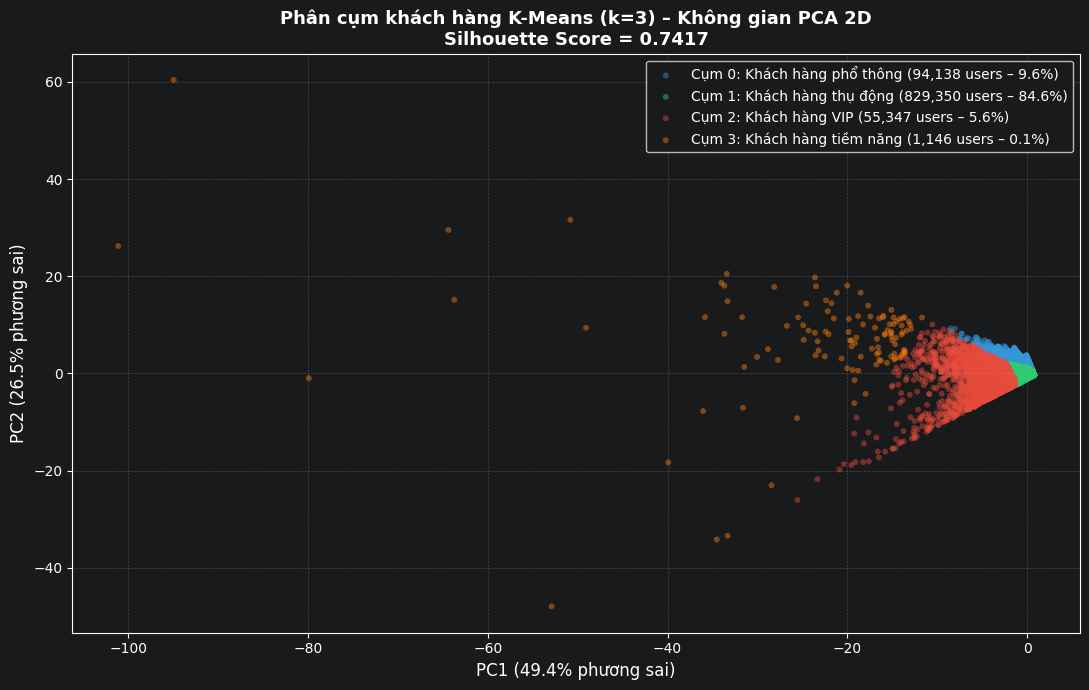

Đã lưu: pca_kmeans_clusters.png


In [8]:
# Vẽ biểu đồ phân cụm PCA 2D (k=4)
# 1. Khai báo tên gọi và màu sắc cho các nhóm (cụm)
CLUSTER_NAMES = {
   0: "Khách hàng tiềm năng",
   1: "Khách hàng thụ động",
   2: "Khách hàng phổ thông ",
   3: "Khách hàng VIP"
}
CLUSTER_COLORS = {
   0: "#3498DB",   # Xanh dương
   1: "#2ECC71",   # Xanh lá
   2: "#E74C3C",   # Đỏ
   3: "#ff7f0e",  # Cam
}
# 2. Tạo khung biểu đồ
fig, ax = plt.subplots(figsize=(11, 7))
# 3. Vẽ dữ liệu của từng nhóm lên biểu đồ
# Vòng lặp này duyệt qua lần lượt từng nhóm khách hàng (0, 1, 2, 3)
for cid in sorted(df_pca_pd["prediction"].unique()):
   # Tạo một bộ lọc để chỉ lấy các dữ liệu thuộc về nhóm hiện tại (nhóm cid)
   mask = df_pca_pd["prediction"] == cid
   # Đếm xem có bao nhiêu khách hàng nằm trong nhóm này
   count = df_clustered.filter(F.col("prediction") == cid).count()
   # Tính tỉ lệ phần trăm của nhóm này so với tổng số 979.981 khách hàng
   pct = count / 979981 * 100
   ax.scatter(
       # Trục x lấy giá trị cột PC1, Trục y lấy giá trị cột PC2
       df_pca_pd.loc[mask, "PC1"],
       df_pca_pd.loc[mask, "PC2"],
       c=CLUSTER_COLORS[cid],
       label=f"Cụm {cid}: {CLUSTER_NAMES[cid]} ({count:,} users – {pct:.1f}%)",
       alpha=0.45, s=18, edgecolors='none'
   )
ax.set_xlabel(f"PC1 ({explained_variance[0]*100:.1f}% phương sai)", fontsize=12)
ax.set_ylabel(f"PC2 ({explained_variance[1]*100:.1f}% phương sai)", fontsize=12)
ax.set_title(
   f"Phân cụm khách hàng K-Means (k=4) – Không gian PCA 2D\n"
   f"Silhouette Score = {silhouette_final:.4f}",
   fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
# Lưu ảnh
plt.savefig('pca_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: pca_kmeans_clusters.png")